In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
matrix = np.random.randint(0, 100, size=(5, 5))
print(matrix)

row_means = matrix.mean(axis=1)
col_means = matrix.mean(axis=0)
overall_std = matrix.std()

print("Row means:", row_means)
print("Column means:", col_means)
print("Overall std:", overall_std)

[[92 70 49 12 49]
 [24 21 85  5 94]
 [31 18  7 79 44]
 [61 49 60 92 34]
 [76 24 30 15 38]]
Row means: [54.4 45.8 35.8 59.2 36.6]
Column means: [56.8 36.4 46.2 40.6 51.8]
Overall std: 27.896781176329284


In [3]:
mask = matrix > 75      # array of True/False, same shape as matrix
matrix[mask] = -1       # every position where mask is True gets set to -1
print(matrix)

[[-1 70 49 12 49]
 [24 21 -1  5 -1]
 [31 18  7 -1 44]
 [61 49 60 -1 34]
 [-1 24 30 15 38]]


In [4]:
arr = np.random.randint(0, 100, size=100)

moving_avg = (arr[0:-2] + arr[1:-1] + arr[2:]) / 3
print(moving_avg)
print(len(moving_avg))   # should be 98 — length 100 minus (window - 1)

[38.33333333 39.66666667 25.33333333 38.         41.33333333 57.33333333
 38.66666667 64.66666667 41.66666667 51.33333333 50.33333333 44.66666667
 61.33333333 51.66666667 64.66666667 41.66666667 22.66666667 20.66666667
 33.         53.         48.66666667 57.33333333 58.         66.33333333
 57.66666667 53.         63.33333333 78.33333333 65.         53.33333333
 32.33333333 50.66666667 37.33333333 54.         37.33333333 62.
 68.33333333 88.         66.33333333 61.33333333 68.         82.66666667
 57.         33.33333333 28.33333333 43.66666667 59.33333333 44.
 49.         35.33333333 56.         55.33333333 48.         58.
 54.         75.66666667 69.33333333 61.66666667 68.66666667 63.
 70.33333333 68.33333333 53.66666667 54.33333333 31.         31.66666667
 45.         38.33333333 49.         26.66666667 44.66666667 27.66666667
 45.         35.33333333 61.33333333 55.33333333 63.33333333 54.66666667
 49.         45.33333333 38.66666667 25.33333333 18.         29.66666667
 49.333333

In [5]:
titanic = sns.load_dataset("titanic")

print(titanic.shape)          # (rows, columns) as a tuple
print(titanic["age"].dtype)   # dtype of just the age column

(891, 15)
float64


In [6]:
survival_rates = titanic.groupby(["class", "sex"], observed=True)["survived"].mean()
print(survival_rates)

class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


C:\Users\T0517ZR\AppData\Local\Temp\ipykernel_12364\602728937.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rates = titanic.groupby(["class", "sex"])["survived"].mean()


In [7]:
titanic["age"] = titanic["age"].fillna(
    titanic.groupby("class", observed=True)["age"].transform("median")
)

print(titanic["age"].isna().sum())   # should now be 0

0


C:\Users\T0517ZR\AppData\Local\Temp\ipykernel_12364\334230719.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("class")["age"].transform("median")


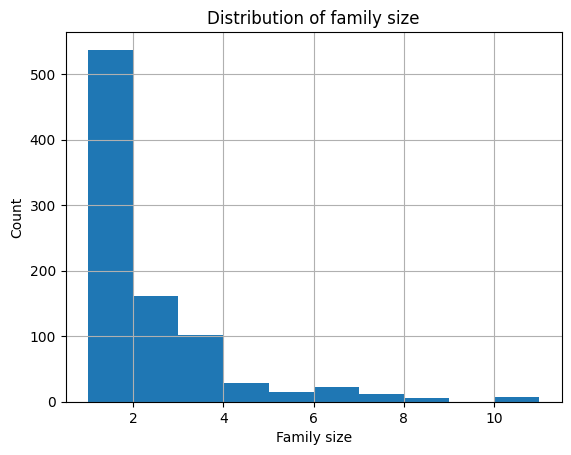

In [8]:
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

titanic["family_size"].hist(bins=range(1, 12))
plt.xlabel("Family size")
plt.ylabel("Count")
plt.title("Distribution of family size")
plt.show()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

texts = [
    "the rocket launched into orbit around the moon",
    "nasa announced a new mission to mars",
    "the car engine needs an oil change",
    "he bought new tires for his sedan",
    "the spacecraft docked with the space station",
    "the mechanic replaced the brake pads",
    "astronauts conducted a spacewalk today",
    "she took her vehicle in for a tune up",
]
labels = ["space", "space", "auto", "auto", "space", "auto", "space", "auto"]

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ("clf", LogisticRegression(max_iter=1000)),
])

pipe.fit(X_train, y_train)
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

        auto       0.00      0.00      0.00       1.0
       space       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



In [ ]:
from datasets import load_dataset

imdb = load_dataset("imdb")
df_train = imdb["train"].to_pandas()
df_test = imdb["test"].to_pandas()

print(df_train.shape, df_test.shape)
df_train.head()

In [ ]:
import os

os.makedirs("data/raw", exist_ok=True)

df_train.to_csv("data/raw/imdb_train.csv", index=False)
df_test.to_csv("data/raw/imdb_test.csv", index=False)